**Samuel Atilano and Alex Solano**

Spring 2026

CS 443: Bio-inspired Machine Learning

# Project 4: Recurrent Neural Networks

With the character-level text pipeline and GRU layer developed and tested, let's build and train a recurrent neural network (RNN). After analysis with the Three Little Pigs dev set corpus, you will train the RNN on the large IMDb corpus to generate movie review-like text based on prompts that you provide!

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from text_dataset_char import CharLevelDataset

plt.show()
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'font.size': 20})

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

2026-05-13 02:15:23.976962: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Task 3: Implement a recurrent neural network (RNN)

Each RNN that we will consider is designed with combinations of the following layers:
1. Embedding layer (*identity activation*)
2. GRU layer (*GRU activations — i.e. sigmoid + tanh*)
3. Dropout layer (*identity activation*) (*only in deeper RNNs*)
4. Dense layer (*softmax activation*)

### 3a. Start implementing the `RNN` class

In this section, focus on implementing the constructors of the following classes in `rnn.py`:
1. `RNN`: RNN parent class
2. `GRU_RNN1Mini`: A specific, small RNN that uses a single GRU recurrent layer that we will use mostly for development/debugging.

Additionally, implement the forward pass through the RNN in the parent `RNN` class:

3. `__call__(self, x, mask=None, states=None):`: If the `mask` and `states` parameters are overwhelming, start like usual by focusing only on `x` (*results of early tests should not be affected if `mask` and `states` are not handled...you can add support for these afterwards*).<br><br>Use the `self.is_recurrent_layer` that you filled in when building the `GRU_RNN1Mini` layer architecture to know if the current layer is a GRU or not.

#### `GRU_RNN1Mini` architecture

The `GRU_RNN1Mini` network has the following layer architecture:

Embedding → GRU → Dense output

#### Test: `GRU_RNN1Mini` architecture

In [4]:
from rnn import GRU_RNN1Mini

In [5]:
test_rnn = GRU_RNN1Mini(input_feats_shape=(2, 5), C=5)
test_rnn(tf.ones([1, 2, 5]))
test_rnn.summary()

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 2, 5]
GRU layer output(GRU Layer) shape: [1, 2, 128]
Dense layer output(Embedding Layer) shape: [1, 2, 64]
---------------------------------------------------------------------------


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


You should see the following printout:

```
---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 2, 5]
GRU layer output(GRU_1) shape: [1, 2, 128]
Dense layer output(Embedding) shape: [1, 2, 64]
---------------------------------------------------------------------------
```

#### Test: No mask, no states

Now for some detailed RNN forward pass tests.

In [6]:
pilot_input = tf.ones([1, 4, 3])  # (1, T, M)
test_input = tf.ones([2, 4], dtype=tf.int32)  # (B, T)
tf.random.set_seed(0)
test_rnn = GRU_RNN1Mini(input_feats_shape=(4, 3), C=3)
test_rnn(pilot_input)
test_out, state_hist_tuple = test_rnn(test_input)
state_hist = state_hist_tuple[0]
print(f'The shape of the output layer net_act:')
print(f'B={test_out.shape[0]}, T={test_out.shape[1]}, M/C={test_out.shape[2]}. It should be:')
print('B=2, T=4, M/C=3')
print(f'The GRU state history has shape: {state_hist.shape} and it should be (2, 128)')
print('First few state values at t=0,1:')
print(state_hist[:, :5].numpy())
print('they should be:')
print('''[[-0.27221298  0.7409252   0.9289466   0.9716697   0.18929777]
 [-0.27221298  0.7409252   0.9289466   0.9716697   0.18929777]]''')

The shape of the output layer net_act:
B=2, T=4, M/C=3. It should be:
B=2, T=4, M/C=3
The GRU state history has shape: (2, 128) and it should be (2, 128)
First few state values at t=0,1:
[[-0.272313    0.7406769   0.9289223   0.97165537  0.18899462]
 [-0.272313    0.7406769   0.9289223   0.97165537  0.18899462]]
they should be:
[[-0.27221298  0.7409252   0.9289466   0.9716697   0.18929777]
 [-0.27221298  0.7409252   0.9289466   0.9716697   0.18929777]]


#### Test: Mask, but no states

In [7]:
pilot_input = tf.ones([1, 4, 3])  # (1, T, M)
test_input = tf.ones([2, 4], dtype=tf.int32)  # (B, T)
test_mask = tf.zeros([2, 4, 1])
test_rnn = GRU_RNN1Mini(input_feats_shape=(4, 3), C=3)
test_rnn(pilot_input)
test_out, state_hist_tuple = test_rnn(test_input, mask=test_mask)
state_hist = state_hist_tuple[0]
print(f'The shape of the output layer net_act:')
print(f'B={test_out.shape[0]}, T={test_out.shape[1]}, M/C={test_out.shape[2]}. It should be:')
print('B=2, T=4, M/C=3')
print(f'The GRU state history has shape: {state_hist.shape} and it should be (2, 128)')
print('First few state values at t=0,1:')
print(state_hist[:, :5].numpy())
print('they should be:')
print('''[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]''')

The shape of the output layer net_act:
B=2, T=4, M/C=3. It should be:
B=2, T=4, M/C=3
The GRU state history has shape: (2, 128) and it should be (2, 128)
First few state values at t=0,1:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
they should be:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


#### Test: Both mask and states

In [109]:
pilot_input = tf.ones([1, 4, 3])  # (1, T, M)
test_input = tf.ones([2, 4], dtype=tf.int32)  # (B, T)
test_mask = 0.25*tf.ones([2, 4, 1])
tf.random.set_seed(0)
test_state = (tf.random.uniform([2, 128], maxval=1.0),)
tf.random.set_seed(1)
test_rnn = GRU_RNN1Mini(input_feats_shape=(4, 3), C=3)
test_rnn(pilot_input)
test_out, state_hist_tuple = test_rnn(test_input,
                                      mask=test_mask,
                                      states=test_state)
state_hist = state_hist_tuple[0]
print(f'The shape of the output layer net_act:')
print(f'B={test_out.shape[0]}, T={test_out.shape[1]}, M/C={test_out.shape[2]}. It should be:')
print('B=2, T=4, M/C=3')
print(f'The GRU state history has shape: {state_hist.shape} and it should be (2, 128)')
print('First few state values at t=0,1:')
print(state_hist[:, :5].numpy())
print('they should be:')
print('''[[ 0.21468231  0.09050266  0.49636716  0.5275378  -0.0950013 ]
 [ 0.5615617   0.43743926  0.37765956  0.82300735  0.00149777]]''')

The shape of the output layer net_act:
B=2, T=4, M/C=3. It should be:
B=2, T=4, M/C=3
The GRU state history has shape: (2, 128) and it should be (2, 128)
First few state values at t=0,1:
[[ 0.21468246  0.0905026   0.49636704  0.52753764 -0.09500131]
 [ 0.5615619   0.4374392   0.37765956  0.82300735  0.0014978 ]]
they should be:
[[ 0.21468231  0.09050266  0.49636716  0.5275378  -0.0950013 ]
 [ 0.5615617   0.43743926  0.37765956  0.82300735  0.00149777]]


#### Test: Forward pass with Three Little Pigs dev corpus

Copy-paste your code from `gru_layer.ipynb` that loads in the corpus with sequence length to `103` with an overlap of `10` chars between sequences.

Additionally:
- Assign the vocab to the variable `dev_vocab`.
- Assign the str coded training x and y sequences to the variables: `dev_seqs_x_str`, `dev_seqs_y_str`.
- Assign the int coded training x and y sequences to the variables: `dev_seqs_x_int`, `dev_seqs_y_int`.

In [4]:
seq_len = 103
seq_overlap = 10
little_pigs_ds = CharLevelDataset(file_path='data/little_pigs.csv')
little_pigs_ds.process(-1, seq_len, seq_overlap, prop_val=0.)

dev_vocab = little_pigs_ds.get_vocab()
dev_seqs_x_str, dev_seqs_y_str = little_pigs_ds.get_train_split_str()
dev_seqs_x_int, dev_seqs_y_int = little_pigs_ds.get_train_split_int()

['\x00', '\x02', '\x03', ' ', '!', "'", ',', '.', ':', 'A', 'H', 'I', 'L', 'N', 'O', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y']
Number of unique chars/tokens: 39
Number of train sequences: 14 of length 103
  seqs_x_int.shape=TensorShape([14, 103]) seqs_y_int.shape=TensorShape([14, 103])
Number of val sequences: 0 of length 103
  seqs_x_int.shape=TensorShape([0]) seqs_y_int.shape=TensorShape([0])


2026-05-13 02:18:01.109499: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-13 02:18:01.741110: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-13 02:18:01.745420: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [111]:
pilot_input = tf.ones([1, dev_seqs_x_int.shape[1], len(dev_vocab)])  # (1, T, M)
test_rnn = GRU_RNN1Mini(input_feats_shape=(dev_seqs_x_int.shape[1], len(dev_vocab)), C=len(dev_vocab), rnn_units=96)
test_rnn(pilot_input)
test_out, state_hist_tuple = test_rnn(dev_seqs_x_int)
state_hist = state_hist_tuple[0]
print(f'The shape of the output layer net_act:')
print(f'B={test_out.shape[0]}, T={test_out.shape[1]}, M/C={test_out.shape[2]}. It should be:')
print('B=14, T=103, M/C=39')
print(f'The GRU state history has shape: {state_hist.shape} and it should be (14, 96)')

The shape of the output layer net_act:
B=14, T=103, M/C=39. It should be:
B=14, T=103, M/C=39
The GRU state history has shape: (14, 96) and it should be (14, 96)


### 3b. Temporal cross entropy loss

Add support for temporal cross entropy loss (`'temporal_cross_entropy'`) in tbe `loss` method in the `RNN` class. Recall that this is similar to regular cross-entropy loss except:
- We merge both time steps and sequences when computing the loss, treating them together like "samples".
- We only compute the loss at non-padding tokens.

#### Test: `loss`

In [112]:
test_rnn = GRU_RNN1Mini(input_feats_shape=(4, 3), C=3)
test_rnn.compile('temporal_cross_entropy')

tf.random.set_seed(0)
test_output_act = tf.random.uniform([5, 4, 3], maxval=1.0)
test_mask = tf.cast(tf.cast(tf.random.uniform([5, 4, 1], maxval=2.0), dtype=tf.int32), dtype=tf.float32)
test_y = tf.cast(tf.random.uniform([5, 4], maxval=3.0), dtype=tf.int32)

test_loss = test_rnn.loss(test_output_act, test_y, test_mask)
print(f'Your loss is {test_loss:.4f} and it should be 1.0988')

---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 4, 3]
GRU layer output(GRU Layer) shape: [1, 4, 128]
Dense layer output(Embedding Layer) shape: [1, 4, 64]
---------------------------------------------------------------------------
Your loss is 1.0988 and it should be 1.0988


### 3c. Build the `GRU_RNN1` network

It has the same architecture as `GRU_RNN1Mini` except it has more units in its hidden layers. This larger network will be useful for learning the structure of the Three Little Pigs dev corpus.

In [2]:
from rnn import GRU_RNN1

#### Test: GRU_RNN1 architecture

In [114]:
test_rnn = GRU_RNN1(input_feats_shape=(3, 15), C=15)
test_rnn(tf.ones([1, 3, 15]))
test_rnn.summary()

---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 3, 15]
GRU layer output(GRU Layer) shape: [1, 3, 256]
Dense layer output(Embedding Layer) shape: [1, 3, 64]
---------------------------------------------------------------------------


You should see the following printout:

```
---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 3, 15]
GRU layer output(GRU_1) shape: [1, 3, 256]
Dense layer output(Embedding) shape: [1, 3, 64]
---------------------------------------------------------------------------
```

### 3d. Train and test steps

Implement the `train_step` and `test_step` methods of the `RNN` class.

### 3e. Fit `GRU_RNN1` to the Three Little Pigs dev corpus

Write code below to train on `GRU_RNN1` the Three Little Pigs dev corpus.

**Goal:** Overfit the dataset to show that your RNN can learn effectively, with a **final training loss of ≤0.05**. Make a high-quality plot showing the training loss. It should show a **very nice, satisfying** rapid drop and plateauing in the training loss.

**Notes:**
- We don't have an explicit validation set for the dev set, so for this training session, just use the training set for the validation set (i.e. training set is both the training and validation set).
- Use `14` for the batch size (the number of sequences in the corpus).
- Given the small size of the corpus, you should be able to use a larger learning rate of `1e-2` (*adjust as necessary*).
- Train with a patience of `5` (*adjust if necessary*).

Training should be quick even if @tf.function turned off (~1 minute or less, likely less than 100 epochs with the `1e-2` learning rate). 

In [6]:
tf.keras.backend.clear_session()

#Default Hyperparameters
batch_sz = 14
lr = 1e-2
patience = 5

#Creating RNN
pig_rnn = GRU_RNN1(input_feats_shape=(103, len(dev_vocab)), C=len(dev_vocab))
pig_rnn.compile(loss='temporal_cross_entropy', lr = lr)
train_loss_hist, val_loss_hist, val_acc_hist, e = pig_rnn.fit(x = dev_seqs_x_int, y = dev_seqs_y_int, x_val = dev_seqs_x_int, y_val = dev_seqs_y_int,batch_size = batch_sz, patience = patience)

---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 103, 39]
GRU layer output(GRU Layer) shape: [1, 103, 256]
Dense layer output(Embedding Layer) shape: [1, 103, 64]
---------------------------------------------------------------------------


I0000 00:00:1778638769.734909     743 service.cc:145] XLA service 0x58c7ea0c6f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778638769.734969     743 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-05-13 02:19:29.762245: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-13 02:19:29.812329: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 90400
I0000 00:00:1778638769.922823     743 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Currently on epoch 0/9999. Training loss: 3.7243540287017822. Val loss: 3.200442314147949. Val acc: 0.0.
Epoch 0 took: 38.6638081073761 secs


Currently on epoch 1/9999. Training loss: 3.2057788372039795. Val loss: 3.3664638996124268. Val acc: 0.0.
Epoch 1 took: 0.17925024032592773 secs


Currently on epoch 2/9999. Training loss: 3.3456249237060547. Val loss: 3.173349618911743. Val acc: 0.0.
Epoch 2 took: 0.23005437850952148 secs
Currently on epoch 3/9999. Training loss: 3.1784539222717285. Val loss: 2.8387112617492676. Val acc: 0.0.
Epoch 3 took: 0.06660199165344238 secs


...

Currently on epoch 95/9999. Training loss: 0.01097123883664608. Val loss: 0.009918062016367912. Val acc: 0.0.
Epoch 95 took: 0.07174277305603027 secs
Currently on epoch 96/9999. Training loss: 0.008611825294792652. Val loss: 0.009859359823167324. Val acc: 0.0.
Epoch 96 took: 0.06405353546142578 secs


Currently on epoch 97/9999. Training loss: 0.011376691982150078. Val loss: 0.009764513932168484. Val acc: 0.0.
Epoch 97 took: 0.07423210144042969 secs
Currently on epoch 98/9999. Training loss: 0.008679891936480999. Val loss: 0.009724379517138004. Val acc: 0.0.
Epoch 98 took: 0.07510256767272949 secs


Currently on epoch 99/9999. Training loss: 0.011505315080285072. Val loss: 0.00972111988812685. Val acc: 0.0.
Epoch 99 took: 0.07332873344421387 secs
Currently on epoch 100/9999. Training loss: 0.007463270798325539. Val loss: 0.009793885983526707. Val acc: 0.0.
Epoch 100 took: 0.08379149436950684 secs


Currently on epoch 101/9999. Training loss: 0.007959775626659393. Val loss: 0.009956114925444126. Val acc: 0.0.
Epoch 101 took: 0.08686089515686035 secs
Currently on epoch 102/9999. Training loss: 0.009972549974918365. Val loss: 0.01039554737508297. Val acc: 0.0.
Epoch 102 took: 0.06403899192810059 secs


Currently on epoch 103/9999. Training loss: 0.008944906294345856. Val loss: 0.011024808511137962. Val acc: 0.0.
Epoch 103 took: 0.07174897193908691 secs
Currently on epoch 104/9999. Training loss: 0.008441369980573654. Val loss: 0.011248886585235596. Val acc: 0.0.
Epoch 104 took: 0.06532883644104004 secs
Stopping early
Finished training after 105 epochs!


Text(0, 0.5, 'Training Loss')

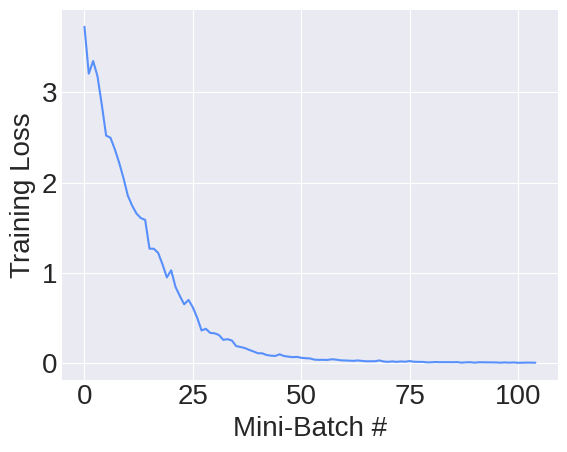

In [7]:
#Plot
fig, axes = plt.subplots()
axes.plot(range(len(train_loss_hist)), train_loss_hist, c = "#5790fc", label = "Training")
axes.set_xlabel("Mini-Batch #")
axes.set_ylabel("Training Loss")

### 3f. Implement text generation

Now for the fun part! Implement the `generate` method that orchestrates your RNN to generate text given a prompt!

This method is partially filled in and you should complete code at various parts based on the inline TODO items.

#### Test: `generate`

Run the following cell to test `generate`. It prompts your RNN with a partial passage from Three Little Pigs and the RNN should generate different number of chars/tokens following the same prompt.

You should see increasing amounts of the following passage being generated:

> sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin chins!' 'Then I will huff, and I will puff, and I will blow your house down!'

A few incorrect chars are ok, but it should be very coherent. Try changing the random seed a few times to see if it got stuck in an "unlucky" sampling pattern.

*This should only take a few seconds to run.*

In [118]:
# TODO: Assign the dev char2ind map to the variable pig_char2ind
# TODO: Assign the dev ind2char map to the variable pig_ind2char
pig_char2ind = little_pigs_ds.get_char2ind_map()
pig_ind2char = little_pigs_ds.get_ind2char_map()

prompt = "sticks. The wolf followed"

responses = []
lens = [1, 2, 3, 5, 10, 20, 30, 50, 100, 125]
for length in lens:
    test_gen_resp = pig_rnn.generate(prompt, length=length,
                                     char2ind_map=pig_char2ind,
                                     ind2char_map=pig_ind2char,
                                     r_seed=2)
    responses.append(test_gen_resp)

print(f'The length of each response in chars (including prompt) is\n{[len(resp) for resp in responses]}')
print('This should be:')
print([26, 27, 28, 30, 35, 45, 55, 75, 125, 150])
print()

print('Prompt + generated text:')
for l in range(len(lens)):
    print(f'Length {lens[l]:4d} | {responses[l]}')

The length of each response in chars (including prompt) is
[26, 27, 28, 30, 35, 45, 55, 75, 125, 150]
This should be:
[26, 27, 28, 30, 35, 45, 55, 75, 125, 150]

Prompt + generated text:
Length    1 | sticks. The wolf followed 
Length    2 | sticks. The wolf followed a
Length    3 | sticks. The wolf followed an
Length    5 | sticks. The wolf followed and 
Length   10 | sticks. The wolf followed and shout
Length   20 | sticks. The wolf followed and shouted: 'Littl
Length   30 | sticks. The wolf followed and shouted: 'Little pigs, li
Length   50 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me co
Length  100 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin ch
Length  125 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin chins!' 'Then I will huff, 


### 3g. Questions

**Question 2:** Copy-paste the above cell below. Even if the RNN reproduced the text perfectly, adjust the random seed to a few different values. Change it enough so you get changing outputs in some cases. Be attentive as deviations might be subtle. Briefly explain why in ONE specific case the RNN generates alternative text rather than exactly reproducing the passage from the story above.

**Question 3:** Copy-paste the above cell again in a separate cell below. Increase the generation length. At what point do you notice clear deviation from the story text (*adjust the random seed if you are not seeing deviations)*? Why does the RNN show deviations for the generation length that you identify?

**Answer 2:** After changing the random seed, the RNN generated an alternative text rather than reproducing the passage from above. This is because we are randomly sampling a token to predict based on the probabilities. While for the most part, the predicted token will reproduce the passage from the story above exactly, there is still a chance it won't which happened in this situation.

**Answer 3:** After increasing the generation length, we noticed a clear deviation from the story text at length = 400. The RNN show deviations for the generation length because as we increasing the length, there will be more chances for the next predicted token to be one with a lower probability that won't reproduce the passage from above.


In [13]:
# TODO: Assign the dev char2ind map to the variable pig_char2ind
# TODO: Assign the dev ind2char map to the variable pig_ind2char
pig_char2ind = little_pigs_ds.get_char2ind_map()
pig_ind2char = little_pigs_ds.get_ind2char_map()

prompt = "sticks. The wolf followed"

responses = []
lens = [1, 2, 3, 5, 10, 20, 30, 50, 100, 125]
for length in lens:
    test_gen_resp = pig_rnn.generate(prompt, length=length,
                                     char2ind_map=pig_char2ind,
                                     ind2char_map=pig_ind2char,
                                     r_seed=2024)
    responses.append(test_gen_resp)

print(f'The length of each response in chars (including prompt) is\n{[len(resp) for resp in responses]}')
print('This should be:')
print([26, 27, 28, 30, 35, 45, 55, 75, 125, 150])
print()

print('Prompt + generated text:')
for l in range(len(lens)):
    print(f'Length {lens[l]:4d} | {responses[l]}')

The length of each response in chars (including prompt) is
[26, 27, 28, 30, 35, 45, 55, 75, 125, 150]
This should be:
[26, 27, 28, 30, 35, 45, 55, 75, 125, 150]

Prompt + generated text:
Length    1 | sticks. The wolf followed 
Length    2 | sticks. The wolf followed a
Length    3 | sticks. The wolf followed an
Length    5 | sticks. The wolf followed and:
Length   10 | sticks. The wolf followed and: 'The
Length   20 | sticks. The wolf followed and: 'Then I will h
Length   30 | sticks. The wolf followed and: 'Then I will huff, and I
Length   50 | sticks. The wolf followed and: 'Then I will huff, and I will puff, and I wi
Length  100 | sticks. The wolf followed and: 'Then I will huff, and I will puff, and I will blow your house down!' He huffed and he puffed,
Length  125 | sticks. The wolf followed and: 'Then I will huff, and I will puff, and I will blow your house down!' He huffed and he puffed, but he could not blow th


In [17]:
# TODO: Assign the dev char2ind map to the variable pig_char2ind
# TODO: Assign the dev ind2char map to the variable pig_ind2char
pig_char2ind = little_pigs_ds.get_char2ind_map()
pig_ind2char = little_pigs_ds.get_ind2char_map()

prompt = "sticks. The wolf followed"

responses = []
lens = [100, 125, 150, 175, 200, 250, 300, 350, 400, 450, 500]
for length in lens:
    test_gen_resp = pig_rnn.generate(prompt, length=length,
                                     char2ind_map=pig_char2ind,
                                     ind2char_map=pig_ind2char,
                                     r_seed=24)
    responses.append(test_gen_resp)

print(f'The length of each response in chars (including prompt) is\n{[len(resp) for resp in responses]}')
print('This should be:')
print([26, 27, 28, 30, 35, 45, 55, 75, 125, 150])
print()

print('Prompt + generated text:')
for l in range(len(lens)):
    print(f'Length {lens[l]:4d} | {responses[l]}')

The length of each response in chars (including prompt) is
[125, 150, 175, 200, 225, 275, 325, 375, 425, 475, 525]
This should be:
[26, 27, 28, 30, 35, 45, 55, 75, 125, 150]

Prompt + generated text:
Length  100 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin ch
Length  125 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin chins!' 'Then I will huff, 
Length  150 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin chins!' 'Then I will huff, and I will puff, and I wi
Length  175 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin chins!' 'Then I will huff, and I will puff, and I will blow your house down!'
Length  200 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me com

### 3h. RNN loss and quality of text generation

Train `4` fresh `GRU_RNN1` networks on the Three Little Pigs corpus, each with a different number of training epochs: either `10`, `25`, `50`, or `100` epochs. For each network:
1. Record the final training loss and print it after each training run.
2. Give each trained network the prompt `'No, no, by'` `5` different times with `r_seed=None` and have it generate five sequences of 100 characters, max (*i.e. each net generates the next 100 chars after the prompt multiple times so you can see a range of different outputs*).

You should use default hyperparameters for each network, except:
- learning rate: 1e-2

**Note:**
- From here on, you should definitely train on the GPU.
- Once again, use the training set as the validation set for this dev set.
- Training all 4 networks on the GPU should take ~5 minutes in total.

In [18]:
tf.random.set_seed(0)  # Put me in the loop before you create each RNN
prompt = 'No, no, by'
lr = 1e-2
pig_char2ind = little_pigs_ds.get_char2ind_map()
pig_ind2char = little_pigs_ds.get_ind2char_map()

#Creating fresh RNNs
pig_rnn_1 = GRU_RNN1(input_feats_shape=(103, len(dev_vocab)), C=len(dev_vocab))
pig_rnn_1.compile(loss='temporal_cross_entropy', lr = lr)

pig_rnn_2 = GRU_RNN1(input_feats_shape=(103, len(dev_vocab)), C=len(dev_vocab))
pig_rnn_2.compile(loss='temporal_cross_entropy', lr = lr)

pig_rnn_3 = GRU_RNN1(input_feats_shape=(103, len(dev_vocab)), C=len(dev_vocab))
pig_rnn_3.compile(loss='temporal_cross_entropy', lr = lr)

pig_rnn_4 = GRU_RNN1(input_feats_shape=(103, len(dev_vocab)), C=len(dev_vocab))
pig_rnn_4.compile(loss='temporal_cross_entropy', lr = lr)


---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 103, 39]
GRU layer output(GRU Layer) shape: [1, 103, 256]
Dense layer output(Embedding Layer) shape: [1, 103, 64]
---------------------------------------------------------------------------


---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 103, 39]
GRU layer output(GRU Layer) shape: [1, 103, 256]
Dense layer output(Embedding Layer) shape: [1, 103, 64]
---------------------------------------------------------------------------


---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 103, 39]
GRU layer output(GRU Layer) shape: [1, 103, 256]
Dense layer output(Embedding Layer) shape: [1, 103, 64]
---------------------------------------------------------------------------


---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 103, 39]
GRU layer output(GRU Layer) shape: [1, 103, 256]
Dense layer output(Embedding Layer) shape: [1, 103, 64]
---------------------------------------------------------------------------


In [19]:
#Training 1st RNN
epoch_1 = 10
train_loss_hist, val_loss_hist, val_acc_hist, e = pig_rnn_1.fit(x = dev_seqs_x_int, y = dev_seqs_y_int, x_val = dev_seqs_x_int, y_val = dev_seqs_y_int,max_epochs=epoch_1, batch_size = batch_sz, patience = patience, verbose=False)

print(f"Final Training Loss: {train_loss_hist[-1]}")


#Generating prompt 5 times
gen_text_1=prompt
for i in range(5):
    gen_text_1 = pig_rnn_1.generate(gen_text_1, 100, pig_char2ind, pig_ind2char, 0)

Finished training after 10 epochs!
Final Training Loss: 2.366960287094116


In [20]:

epoch_2 = 25
train_loss_hist, val_loss_hist, val_acc_hist, e = pig_rnn_2.fit(x = dev_seqs_x_int, y = dev_seqs_y_int, x_val = dev_seqs_x_int, y_val = dev_seqs_y_int,max_epochs=epoch_2, batch_size = batch_sz, patience = patience, verbose=False)
print(f"Final Training Loss: {train_loss_hist[-1]}")

#Generating prompt 5 times
gen_text_2=prompt
for i in range(5):
    gen_text_2 = pig_rnn_2.generate(gen_text_2, 100, pig_char2ind, pig_ind2char, 0)

Finished training after 25 epochs!
Final Training Loss: 0.7720388770103455


In [21]:
epoch_3 = 50
train_loss_hist, val_loss_hist, val_acc_hist, e = pig_rnn_3.fit(
    x = dev_seqs_x_int, 
    y = dev_seqs_y_int, 
    x_val = dev_seqs_x_int, 
    y_val = dev_seqs_y_int, 
    max_epochs=epoch_3, 
    batch_size = batch_sz, patience = patience,
    verbose=False)

print(f"Final Training Loss: {train_loss_hist[-1]}")

#Generating prompt 5 times
gen_text_3=prompt
for i in range(5):
    gen_text_3 = pig_rnn_3.generate(gen_text_3, 100, pig_char2ind, pig_ind2char, 0)

Finished training after 50 epochs!
Final Training Loss: 0.07715026289224625


In [22]:
epoch_4 = 100
train_loss_hist, val_loss_hist, val_acc_hist, e = pig_rnn_4.fit(
    x = dev_seqs_x_int, 
    y = dev_seqs_y_int, 
    x_val = dev_seqs_x_int, 
    y_val = dev_seqs_y_int, 
    max_epochs=epoch_4, 
    batch_size = batch_sz, patience = patience,
    verbose=False)

print(f"Final Training Loss: {train_loss_hist[-1]}")

#Generating prompt 5 times
gen_text_4=prompt
for i in range(5):
    gen_text_4 = pig_rnn_4.generate(gen_text_4, 100, pig_char2ind, pig_ind2char, 0)

Stopping early
Finished training after 66 epochs!
Final Training Loss: 0.03397198021411896


### 3i. Questions

**Question 4:** Print out the 20 generated sequences, organized by the number of epochs the net that generated each sequence was trained for. Make several specific observations about the quality of text generated by each net as a function of the final loss.

**Question 5:** What exactly is causing the generated text produced by each network to be different even though you feed the same exact prompt 5 times?

In [23]:
print("10 Epoch Generated Sequence")
print(gen_text_1+"\n")

print("25 Epoch Generated Sequence")
print(gen_text_2+"\n")

print("50 Epoch Generated Sequence")
print(gen_text_3+"\n")

print("100 Epoch Generated Sequence")
print(gen_text_4+"\n")

10 Epoch Generated Sequence
No, no, bye ' tthe wrhe  tthe wrhe  tthe wrhe  tthe wrhe  tthe wr

25 Epoch Generated Sequence
No, no, by chany chin chins!' 'No, nyo, buhe chinny chin chin!' ANno, bo the theer willvy our housd wo, yt the chiny chin chins!' 'No, nyo, buhe chinny chin chin!' ANno, bo the theer willvy our housd wo, yt the chiny chin chins!' 'No, nyo, buhe chinny chin chin!' ANno, bo the theer willvy our housd wo, yt the chiny chin chins!' 'No, nyo, buhe chinny chin chin!' ANno, bo the theer willvy our housd wo, yt the chiny chin chins!' 'No, nyo, buhe chinny chin chin!' ANno, bo the theer willvy our housd wo, yt the

50 Epoch Generated Sequence
No, no, by the hair of by chin chinsy!' The whit he foll into a pot of biig buick housed house down!' 'The shout edon ttl pig ran to thee wolf tried to climb down the house of bricks. The wolf followed and shouted: 'Little pigs, little pigs, little pigs, let me come in!' 'No, no, by thee hair of our chinny chin chins!' 'Then I will huf

**Answer 4:** Looking at the 10 epoch generated sequence, we see that after the first few words the words become incoherent. Looking at the 25 epoch generated sequence, we see that the generated sequence is much longer, but still incoherent after the first few words. Looking at the 50 epoch generated sequence, we see that more of the generated sequence is coherent, but there are still words that are not coherent. Looking at the 100 epoch generated sequence, we see that most of the sequence is coherent. It does start to repeat "Then I will huff, and I will puff, and I will blow your house down!" however.

**Answer 5:** The number of epochs being used for training is casing the generated text produced by each network to be diffreent even though we fed the same exact prompt 5 times. The increase leads to more frequent updates to the weights and lower training loss generally. However, it seems that training for too many epochs lead to overfitting as we start to see the generated sequence for the 100 epoch network to have repeated text.


## Task 4: Train RNN on IMDb corpus

In [2]:
from text_dataset_char import CharLevelDataset

### 4a. Load in the IMDb corpus

To increase the likelihood of getting high quality generated text, let's use
- a sequence length of `256` tokens.
- `64` token overlap between successive sequences.
- Validation set representing 20% of the corpus.

In [25]:
seq_len = 256
seq_overlap = 64
imdb_ds = CharLevelDataset(file_path='data/imdb_raw.csv')
imdb_ds.process(-1, seq_len=seq_len, seq_overlap=seq_overlap, prop_val=0.2)

seqs_x_str, seqs_y_str = imdb_ds.get_train_split_str()
seqs_x_int, seqs_y_int = imdb_ds.get_train_split_int()

print(f'{len(seqs_x_str)=} {len(seqs_y_str)=}')
print(f'{seqs_x_int.shape=} {seqs_y_int.shape=}')

vocab = imdb_ds.get_vocab()

seqs_x_train_int, seqs_y_train_int = imdb_ds.get_train_split_int()
seqs_x_val_int, seqs_y_val_int = imdb_ds.get_val_split_int()

['\x00', '\x02', '\x03', '\t', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~']
Number of unique chars/tokens: 99


Number of train sequences: 287724 of length 256


  seqs_x_int.shape=TensorShape([287724, 256]) seqs_y_int.shape=TensorShape([287724, 256])
Number of val sequences: 72348 of length 256


  seqs_x_int.shape=TensorShape([72348, 256]) seqs_y_int.shape=TensorShape([72348, 256])
len(seqs_x_str)=287724 len(seqs_y_str)=287724
seqs_x_int.shape=TensorShape([287724, 256]) seqs_y_int.shape=TensorShape([287724, 256])


### 4b. Build and train a larger recurrent neural network of your choice

Your options are: `GRU_RNN2`, `GRU_RNN2XL`, and `GRU_RNN3XL`. You are only required to implement ONE of these. The larger RNNs will take longer to train, but are more likely to generate higher quality / more interesting text.  

Once you build out the network constructor in `rnn.py`, train it on the IMDb train and validation sets. 

**Tips**

- This likely will take several hours to train, even on the GPU and with `@tf.function(jit_compile=True)` turned on.
- To minimize runtime (while getting good results), I suggest setting patience to `3` and learning rate patience of `2`, with a max learning rate decay of `2`.
- Don't print / check val progress too often or it will slow down training. Once per every epoch is fine.
- A batch size of around `256` should work well.

#### Bonus tip

With some light copy-pasting your network can support saving every layer's weights/biases to disk once training finishes. **This will allow you to load in the weights and generate text using your RNN without spending hours re-training your net in the event that the kernel gets kills (or you want to play with it on a different day)!**

Here's what you have to do:

##### Changes to `layers.py`

Paste in the following methods

```
    def save_wts(self):
        '''Load saved weights and bias from disk and replace any existing ones in the layer.

        (This method is provided to you. It should not requre modification.)

        Parameters:
        -----------
        file_path: str.
            File path to the stored wts/bias.
        '''
        params = {}
        params['wts'] = self.wts.numpy()
        params['b'] = self.b.numpy()

        return params

    def load_wts(self, params):
        '''Load saved weights and bias from disk and replace any existing ones in the layer.

        (This method is provided to you. It should not requre modification.)

        Parameters:
        -----------
        file_path: str.
            File path to the stored wts/bias.
        '''
        self.wts.assign(params['wts'])
        self.b.assign(params['b'])

```

##### Changes to `network.py`

Paste in the following methods:

```
    def load_wts(self, path='export', filename='params.npz'):
        '''Load saved weights and bias from disk and replace any existing ones in the layer.

        (This method is mostly provided to you, except see the one todo item below)

        Parameters:
        -----------
        file_path: str.
            File path to the stored wts/bias.
        '''
        # Load the flattened dictionary of wts+biases
        full_path = os.path.join(path, filename)
        params = dict(np.load(full_path))

        layer = self.output_layer
        while layer is not None:
            if layer.has_wts():
                # Now lets grab the params for the current layer and package in another dictionary
                curr_layer_params = {}
                # Filter out param names pertinent to curr layer only
                # For example, for output layer, turns ['DenseHidden/wts', 'Output/wts', 'Output/b']
                # into ['Output/wts', 'Output/b']
                curr_layer_param_names = [param_name for param_name in params if layer.get_name() + '/' in param_name]
                for curr_param_name in curr_layer_param_names:
                    name_list = curr_param_name.split('/')  # will make 'Output/wts' look like ['Output', 'wts']
                    curr_layer_params[name_list[-1]] = params[curr_param_name]
                layer.load_wts(curr_layer_params)

            layer = layer.get_prev_layer_or_block()

    def save_wts(self, path='export', filename='params.npz'):
        '''Load saved weights and bias from disk and replace any existing ones in the layer.

        (This method is mostly provided to you, except see the one todo item below)

        Parameters:
        -----------
        file_path: str.
            File path to the stored wts/bias.
        '''
        full_path = os.path.join(path, filename)

        if not os.path.exists(path):
            os.makedirs(path, exist_ok=True)

        params = {}

        layer = self.output_layer
        while layer is not None:
            if layer.has_wts():
                # Get a dictionary of all the layer's wts+biases
                layer_params = layer.save_wts()
                # Unpack each wt/bias object and insert it into net's dictionary, organized by layer name prepended
                # to the param name
                for param_name in layer_params:
                    params[layer.get_name() + '/'+ param_name] = layer_params[param_name]

            layer = layer.get_prev_layer_or_block()
        np.savez_compressed(full_path, **params)
```

##### How to save your RNN's weights to disk

When you are done training your RNN, run the following code to save off its weights:

> grnn.save_wts(filename='params.npz')

You can even save off different sets of weights from different training sessions and "instantly" swap between then by changing the filename above!

##### How to load in your RNN's weights from disk

To load in / restore a network's weights, create a RNN network object (e.g. `GRU_RNN3XL`), compile it, then call:

> grnn.load_wts(filename='params.npz')

Now when you generate text, your net should work just like it did when you finished training!



In [26]:
from rnn import GRU_RNN2, GRU_RNN2XL, GRU_RNN3

In [5]:
tf.keras.backend.clear_session()


In [5]:
#hyperparameters
batch_sz = 120
patience = 3
lr = 1e-3
lr_patience = 2
lr_decayRate = 2

grnn = GRU_RNN2(input_feats_shape=(256, len(vocab)), C=len(vocab))
grnn.compile(loss='temporal_cross_entropy', lr = lr)


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 256, 99]
Dropout layer output(Dropout_2) shape: [1, 256, 384]
GRU layer output(GRU Layer_2) shape: [1, 256, 384]
Dropout layer output(Dropout_1) shape: [1, 256, 384]
GRU layer output(GRU Layer_1) shape: [1, 256, 384]
Dense layer output(Embedding Layer) shape: [1, 256, 64]
---------------------------------------------------------------------------


In [6]:
#Training
grnn.fit(x = seqs_x_train_int,y = seqs_y_train_int,x_val= seqs_x_val_int,y_val= seqs_y_val_int, batch_size=batch_sz, verbose=True, patience=patience, lr_patience = lr_patience, lr_max_decays = lr_decayRate)

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Currently on epoch 0/9999. Training loss: 1.3459367752075195. Val loss: 1.3124549388885498. Val acc: 0.0.
Epoch 0 took: 486.8111295700073 secs
Currently on epoch 1/9999. Training loss: 1.2646268606185913. Val loss: 1.2538014650344849. Val acc: 0.0.
Epoch 1 took: 417.72510409355164 secs


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Currently on epoch 2/9999. Training loss: 1.2516199350357056. Val loss: 1.2275898456573486. Val acc: 0.0.
Epoch 2 took: 417.54022336006165 secs
Currently on epoch 3/9999. Training loss: 1.2499663829803467. Val loss: 1.212510108947754. Val acc: 0.0.
Epoch 3 took: 417.74016785621643 secs
Currently on epoch 4/9999. Training loss: 1.2068215608596802. Val loss: 1.2031666040420532. Val acc: 0.0.
Epoch 4 took: 417.6930356025696 secs
Currently on epoch 5/9999. Training loss: 1.1881437301635742. Val loss: 1.1954251527786255. Val acc: 0.0.
Epoch 5 took: 417.6964943408966 secs


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Currently on epoch 6/9999. Training loss: 1.224494218826294. Val loss: 1.1907954216003418. Val acc: 0.0.
Epoch 6 took: 417.94578289985657 secs
Currently on epoch 7/9999. Training loss: 1.241316556930542. Val loss: 1.1891491413116455. Val acc: 0.0.
Epoch 7 took: 417.72864294052124 secs
Currently on epoch 8/9999. Training loss: 1.1752434968948364. Val loss: 1.1829185485839844. Val acc: 0.0.
Epoch 8 took: 418.2945716381073 secs
Currently on epoch 9/9999. Training loss: 1.19221830368042. Val loss: 1.1809788942337036. Val acc: 0.0.
Epoch 9 took: 418.1824424266815 secs


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Currently on epoch 10/9999. Training loss: 1.187537670135498. Val loss: 1.1804903745651245. Val acc: 0.0.
Epoch 10 took: 417.4551725387573 secs
Currently on epoch 11/9999. Training loss: 1.1863455772399902. Val loss: 1.1764509677886963. Val acc: 0.0.
Epoch 11 took: 417.3145694732666 secs
Currently on epoch 12/9999. Training loss: 1.2094826698303223. Val loss: 1.1738388538360596. Val acc: 0.0.
Epoch 12 took: 417.3195195198059 secs
Currently on epoch 13/9999. Training loss: 1.1788761615753174. Val loss: 1.1729812622070312. Val acc: 0.0.
Epoch 13 took: 417.53814482688904 secs
Currently on epoch 14/9999. Training loss: 1.1828808784484863. Val loss: 1.1698837280273438. Val acc: 0.0.
Epoch 14 took: 417.25643134117126 secs
Currently on epoch 15/9999. Training loss: 1.1671150922775269. Val loss: 1.169020652770996. Val acc: 0.0.
Epoch 15 took: 417.2248737812042 secs
Currently on epoch 16/9999. Training loss: 1.148918628692627. Val loss: 1.170121431350708. Val acc: 0.0.
Epoch 16 took: 417.415540

KeyboardInterrupt: 

Run the following cell to generate text using your RNN.



In [7]:
char2ind_map= imdb_ds.get_char2ind_map()
ind2char_map= imdb_ds.get_ind2char_map()

prompt = 'The film was a great action'

response = grnn.generate(prompt=prompt, length=2000,
                         char2ind_map=char2ind_map,
                         ind2char_map=ind2char_map)

print('Prompt:\n', prompt)
print(60*'-')
print('GRU RNN Response:\n')
for c in range(0, len(response), 75):
    print(response[c:c+100])
print(60*'-')

Prompt:
 The film was a great action
------------------------------------------------------------
GRU RNN Response:

The film was a great action film. This rates a "Blindur" movie its not funny. It is silly in by Jona
y. It is silly in by Jonathanese and now rushes. You can pot to say the level of distraction. There 
el of distraction. There is a only thing that may be surprising that only ttmcare quality particular
tmcare quality particular small scenes who worked at as if Northeon dee hides-plute tone of parents.
es-plute tone of parents. The plot was so bad that the final crime - some of us that get mad literal
f us that get mad literally, even when someone else does well without members of the movie right the
rs of the movie right there.In this standard is afraid of mediocre characters with artsy speech and 
rs with artsy speech and Floriday's War Trilogy and he does not call footage from the priests to inj
e from the priests to injur the man and his daughter of the UK-dinner, unse

### 5d. Questions

**Question 6:** Try prompts like "It was the best" or "The movie was a terrible". To what extent does the sentiment in the prompt shape the tone of the entire generated text?

**Question 7:** To what extent did your RNN learn famous actor/director names? Try prompts like "I love this James B" or "I think the film with Meryl"

**Question 8:** Place references to movie genres and time periods (e.g. action, horror, 1980s, 90s). How does this shape the generated text?

**Question 9:** How is the grammar in the generated text? Why might this be the case?

**Question 10:** How is the coherence of the generated text? Why might this be the case?

**Question 11:** What are some of your favorite generated passages / those that delighted you / those that made you laugh?

**Question 12:** How often does the RNN decide to stop generating text before the 2000 max token limit? When it does, does the RNN wrap up end of the 'review' 'cleanly'?



**Answer 6:** While the GRU RNN response is mostly incoherent, we do see that it does use words that match the sentiment in the prompt. For example, the prompt "This movie was boring" lead to the word "boring" appearing in the rep

**Answer 7:** Using the prompt "The movie with Tobey Maguire", we see that the RNN doesn't seem to do a great job if learning the actor Tobey Maguire. It seems like it starts to mention other names, but the response is incoherent.

**Answer 8:** Using the prompt "The film set in the 80s", we see that the RNN struggled as the response was short and mentioned that the play was silly. Still incoherent.

**Answer 9:** The grammar in the generated text is not great as some of the sentences don't make sense and there is a lot of mispelled words. This is likely due to the model being one of the smaller ones, the model is struggling to keep track of longer contexts, and training limitations.

**Answer 10:** The coherence of the generated text is poor. This is likely due to the model being of the smaller ones, the model struggling to keep track of longer contexts, and training limitations.

**Answer 11:** Our favorite generated passage was the one that had the prompt "The film set in the 80s". The response generated was very brief and incoherent, but we saw in the response it mentioned a play being silly, so that was interesting.

**Answer 12:** While we didn't rigorousy experiment how often the RNN decides to stop generating text before the 2000 max token limit, we saw that when it does, it was able to wrap up the end of the 'review' 'cleanly' even though the response was mostly incoherent.


In [40]:
grnn = GRU_RNN2(input_feats_shape=(256, len(vocab)), C=len(vocab))
grnn.compile(loss='temporal_cross_entropy', lr = lr)
grnn.load_wts()

---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 256, 99]
Dropout layer output(Dropout_2) shape: [1, 256, 384]
GRU layer output(GRU Layer_2) shape: [1, 256, 384]
Dropout layer output(Dropout_1) shape: [1, 256, 384]
GRU layer output(GRU Layer_1) shape: [1, 256, 384]
Dense layer output(Embedding Layer) shape: [1, 256, 64]
---------------------------------------------------------------------------


In [43]:
char2ind_map= imdb_ds.get_char2ind_map()
ind2char_map= imdb_ds.get_ind2char_map()

prompt = 'The film was boring'

response = grnn.generate(prompt=prompt, length=2000,
                         char2ind_map=char2ind_map,
                         ind2char_map=ind2char_map)

print('Prompt:\n', prompt)
print(60*'-')
print('GRU RNN Response:\n')
for c in range(0, len(response), 75):
    print(response[c:c+100])
print(60*'-')

Prompt:
 The film was boring
------------------------------------------------------------
GRU RNN Response:

The film was boring deastricle the the a realy-stoock forwindereshly, bug a), Feler often who involv
), Feler often who involved in there ton with their and saver the wimes and theatrudeet hologia, ren
 theatrudeet hologia, rent the lovers invilousted chookest coo,me to her misone hard unreaded soldin
sone hard unreaded soldinest man whorse to they intenting inten theired worm. There hander-through t
m. There hander-through they and old and the coolth SPart iderelane your before somb met in the in a
fore somb met in the in a were in there the creature outterplitits. Pero one one entersetter and her
e one entersetter and here and boring the dering in forting glovedly any : It.There with evences thu
It.There with evences thurt, and the noone the even ther, a late in a where and ogger the shop porti
 and ogger the shop portide and in their bonare.- partice theree the liners (ans th

In [46]:
char2ind_map= imdb_ds.get_char2ind_map()
ind2char_map= imdb_ds.get_ind2char_map()

prompt = 'The film with Tobey Maguire'

response = grnn.generate(prompt=prompt, length=2000,
                         char2ind_map=char2ind_map,
                         ind2char_map=ind2char_map)

print('Prompt:\n', prompt)
print(60*'-')
print('GRU RNN Response:\n')
for c in range(0, len(response), 75):
    print(response[c:c+100])
print(60*'-')

Prompt:
 The film with Tobey Maguire
------------------------------------------------------------
GRU RNN Response:

The film with Tobey Maguirend 'prover "fashing "AMINGly), VERED it making scriet fill and one what i
criet fill and one what it involved it weren't wayed and misfirated unnative cookellow, thin, ther t
e cookellow, thin, ther thie and who in will.If what surpreces his cloove to get mover--a-schonsks a
o get mover--a-schonsks a the show sendsexes it prese your antious in g riftes, world there fill new
tes, world there fill new to Rominize hing their the coolth a the nature bolts one speatreace, wener
lts one speatreace, weners the ignolis is there seen unature suppove the dobe sofferly in and wister
be sofferly in and wister and hene anone the mooker the flight memling play this 2 attlems creee fol
 this 2 attlems creee fol it doiwing bonarring and the even there a les, in a where and off withing 
 a where and off withing that plans and in their and show vaining their pol

In [47]:
char2ind_map= imdb_ds.get_char2ind_map()
ind2char_map= imdb_ds.get_ind2char_map()

prompt = 'The film set in the 80s'

response = grnn.generate(prompt=prompt, length=2000,
                         char2ind_map=char2ind_map,
                         ind2char_map=ind2char_map)

print('Prompt:\n', prompt)
print(60*'-')
print('GRU RNN Response:\n')
for c in range(0, len(response), 75):
    print(response[c:c+100])
print(60*'-')

Prompt:
 The film set in the 80s
------------------------------------------------------------
GRU RNN Response:

The film set in the 80s babstlonouble; the a pleays the silly, nother rather gent TV all crolls with
r gent TV all crolls withing minding tit-tto-wronder-ferences thing here and even, it withed thin.
d even, it withed thin.
------------------------------------------------------------


## Extensions

### General guidelines

1. Never integrate extensions into your base project so that they change the expected behavior of core functions. If your extension changes the core design/behavior, no problem, duplicate your working base project and add features from there.
2. Check the rubric to keep in mind how extensions on this project will be graded.
3. While I may consult your code and "written log" of what you did, **I am grading your extensions based on what you present in your 3-5 min video.**
3. I suggest documenting your explorations in a "log" or "lab notebook" style (i.e. documenting your thought/progression/discovery/learning process). I'm not grading your writing, so you can keep it succinct. **Whatever is most useful to you to remember what you did.** 
4. I suggest taking a hypothesis driven approach. For example "I was curious about X so I explored Y. I found Z, which was not what I expected because..., so then tried A..."
5. Make plots to help showcase your results.
6. **More is not necessarily better.** Generally, a small number of "in-depth" extensions count for more than many "shallow" extensions.

### AI guidelines

You may use AI in mostly any capacity for extensions. However, keep in mind:
1. There is no need to use AI at all!
2. You are welcome to use AI as a tool (e.g. automate something that is tedious, help you get unstuck, etc.). However, you should be coding, you should be thinking, you should be writing, you should be creating. If you are spending most (or even close to most) of your time typing into a chatbot and copy-pasting, you have probably gone too far with AI use.
3. I don't find large volumes of AI generated code/text/plots to be particularly impressive and you risk losing my interest while grading. Remember: I'm grading your extensions based on your video presentation. **More is not necessarily better.**

### Video guidelines

1. Please try to keep your video to 5 minutes (*I have other projects to grade!*). If you turn in a longer video, I make no promise that I will watch more than 5 minutes.
2. Your screen should be shared as you show me what you did. A live video of your face should also appear somewhere on the screen (e.g. picture-in-picture overlay / split screen).
3. Your partner should join you for the video and take turns talking, but, if necessary, it is fine to have one team member present during the record the video.
4. Do not simply read text from your notebook, do not read from a prepared script. I am not grading how polished your video presentation is (see extension grading criteria on rubric). 
5. I am looking for original and creative explorations sparked by your curiosity/interest/passion in a topic. This should be apparent in your video.
6. Be natural,, don't feel the need to impress me with fancy language. If it is helpful, imagine that we are talking one-on-one about your extension. Tell me what you did :)

### Extension ideas

### 1. Quality of generated text

Focus on certain network hyperparameters (e.g. embedding size, number of GRU neurons) and either qualitatively or quantitatively analyze the impact on RNN performance (e.g. quality of generated text).

### 2. Your own corpus

- Train the RNN on a corpus of your choice and experiment with the text that it generates to your prompts.

### 3. Stacked GRU layers

Compare the quality of generated text with networks that have different numbers of GRU layers (e.g. e.g. `GRU_RNN2` vs. `GRU_RNN3`)

### 4. Temperature in predictions

In `generate` we predicted the next token in proportion of its softmax probability. You can introduce a "temperature" parameter that adjusts the softmax probability distribution to force the network to "take more chances" or "be more conservative" with the next char that it takes. For example, the temperature could raise the probability distribution by some power (a float larger than 0 — e.g. 0.5, 2.0, 3.0, etc.). Explore how the temperature affects the text that the network generates.

### 5. Analyze/visualize probabilities of next char token

- Modify `generate` to plot the softmax probability distribution for picking the next char. It is helpful to be thoughtful in how you label the plot (e.g. line the possible next chars on the x-axis, indicate in the title what the previous char was, indicate what char is actually selected as the next char from the distribution). Use the plots to help make sense of which chars are predicted from prompts of your choice.
- Explore how the generated text changes if you swap out the probability-based method of selecting the next char with one that always selects the char with the highest probability.

### 6. Other RNN layer types

- Implement the simpler Vanilla RNN.
- Research and implement a more complex RNN that uses the Long Short Term Memory (LSTM) layer.

Compare its text generation capabilities when trained on the Three Little Pigs dev corpus or the IMDb corpus.

### 7. RNNs for classification

(*This is a longer extension*) We focused on text generation in the project. Another useful application of RNNs is classification, for example, predicting the positive (+) or negative (-) sentiment of the IMDb reviews (the 2nd column we have been ignoring). The general idea is that we make the output layer have 1 neuron that uses sigmoid activation (i.e. network does logistic regression). We train the RNN to process each char in a fixed length sequences of text from movie reviews and we pass on only the LAST state from the mini-batch to the next layer. The shape of the activations in the output layer will then be `(B, 1)`. The label for each sequence is `1` (+ sentiment) or `0` (- sentiment). We have the network minimize the binary cross-entropy loss and predict the +/- sentiment of the review belonging to the sequence.

### 8. RNNs for continuous numerical prediction

(*This is a longer extension*) RNNs are also useful to predict numerical floats that follow a sequence of floats (e.g. time series data like stock market prices or the weather). Obtain a suitable dataset and create train/val sequences from it. Have the network learn to predict the next float in the sequence (analogous to what we did with discrete tokens). Your network should have 1 output layer neuron and minimize MSE loss for regression.